In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# keep only actual feature columns: f000, f001, ..., f127
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].values
y = df["type"].values

C:\Users\hp\AppData\Local\Temp\ipykernel_39248\2002047843.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_39248\2002047843.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"


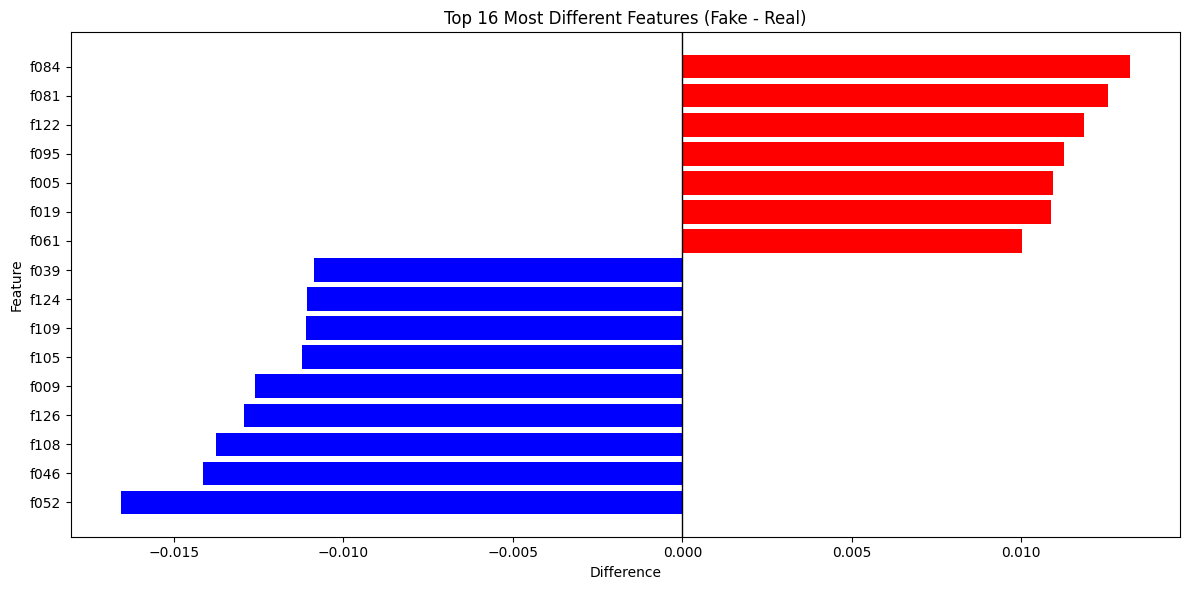

In [8]:
top_k = 16

real_mean = real[feature_cols].mean()
fake_mean = fake[feature_cols].mean()

diff = fake_mean - real_mean

idx_sorted = np.argsort(np.abs(diff.values))[-top_k:]
vals = diff.iloc[idx_sorted]

# sort by actual signed value for visual clarity
order = np.argsort(vals.values)
vals = vals.iloc[order]
labels = [feature_cols[i] for i in idx_sorted[order]]

colors = ["red" if v > 0 else "blue" for v in vals]

plt.figure(figsize=(12,6))
bars = plt.barh(labels, vals, color=colors)

plt.axvline(0, color='black', linewidth=1)
plt.title("Top 16 Most Different Features (Fake - Real)")
plt.xlabel("Difference")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [12]:
print("Real DF rows:", len(real))
print("Real files:", len(real_files))

print("Fake DF rows:", len(fake))
print("Fake files:", len(fake_files))

Real DF rows: 792
Real files: 99
Fake DF rows: 792
Fake files: 99


In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Folder paths
# -----------------------------
real_folder = r"D:/KLAUS/Vis_Final_Project/gridimages2_npy_test_real"
fake_folder = r"D:/KLAUS/Vis_Final_Project/gridimages2_npy_output_fake"

# -----------------------------
# 2. Make sure slice_idx is int
# -----------------------------
real["slice_idx"] = real["slice_idx"].astype(int)
fake["slice_idx"] = fake["slice_idx"].astype(int)

# -----------------------------
# 3. Build file path from volume_file
#    volume_file already contains full .npy filename
# -----------------------------
real["path"] = real["volume_file"].apply(lambda x: os.path.join(real_folder, x))
fake["path"] = fake["volume_file"].apply(lambda x: os.path.join(fake_folder, x))

# -----------------------------
# 4. Verify mapping
# -----------------------------
print("Real example path:", real["path"].iloc[0])
print("Fake example path:", fake["path"].iloc[0])

print("Real exists:", os.path.exists(real["path"].iloc[0]))
print("Fake exists:", os.path.exists(fake["path"].iloc[0]))

Real example path: D:/KLAUS/Vis_Final_Project/gridimages2_npy_test_real\ct1000_NBIADownloadDir_NLST_100005_01-02-1999-NLST-LSS-72969_2-0OPAGELS16B3702.514060.00.11.375-43455_0.npy
Fake example path: D:/KLAUS/Vis_Final_Project/gridimages2_npy_output_fake\mask_ct1000_NBIADownloadDir_NLST_100005_01-02-1999-NLST-LSS-72969_2-0OPAGELS16B3702.514060.00.11.375-43455_0.npy
Real exists: True
Fake exists: True


In [77]:
def show_feature_slices(df_subset, feature_name, title, n=5):
    plt.figure(figsize=(3 * n, 4))

    for i, row in enumerate(df_subset.head(n).itertuples(index=False)):
        vol = np.load(row.path)
        sidx = int(row.slice_idx)

        if vol.ndim == 3:
            if sidx < 0 or sidx >= vol.shape[0]:
                raise IndexError(f"slice_idx {sidx} out of range for volume shape {vol.shape}")
            img = vol[sidx]
        elif vol.ndim == 2:
            img = vol
        else:
            raise ValueError(f"Unsupported volume shape: {vol.shape}")

        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{title}\n{feature_name}={getattr(row, feature_name):.2f}\nslice={sidx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

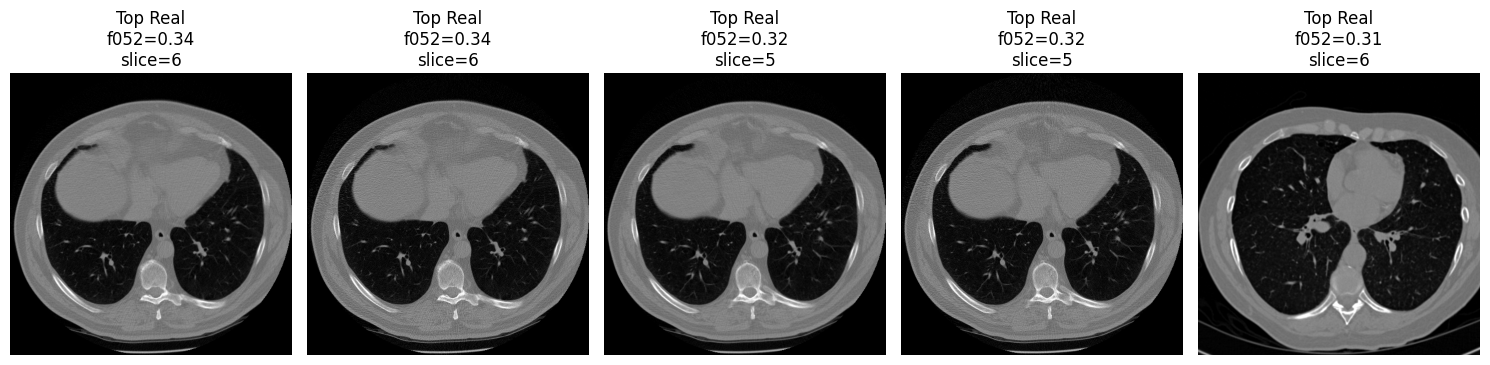

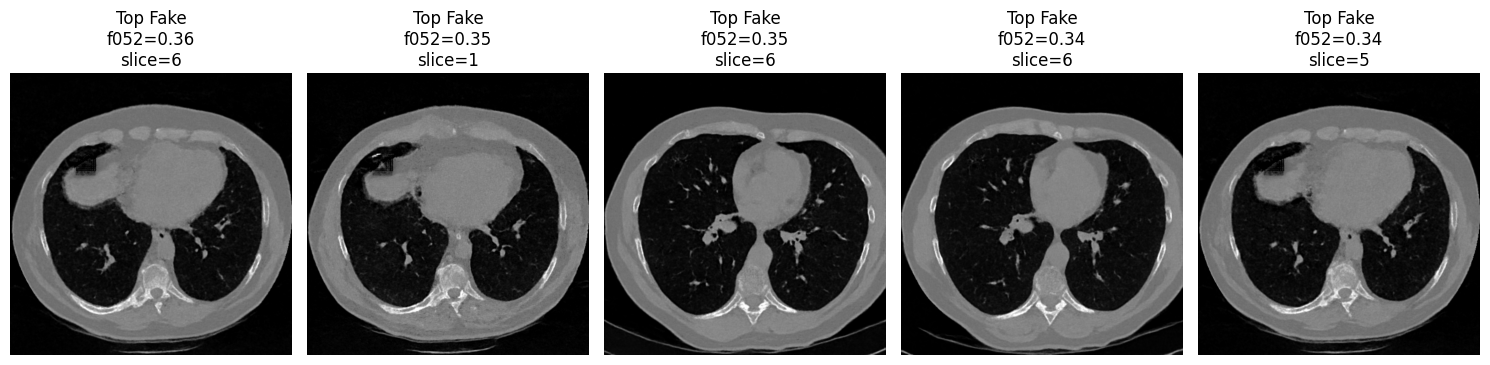

In [78]:
feature = "f052"

top_real = real.sort_values(by=feature, ascending=False).head(5)
top_fake = fake.sort_values(by=feature, ascending=False).head(5)

show_feature_slices(top_real, feature, "Top Real")
show_feature_slices(top_fake, feature, "Top Fake")

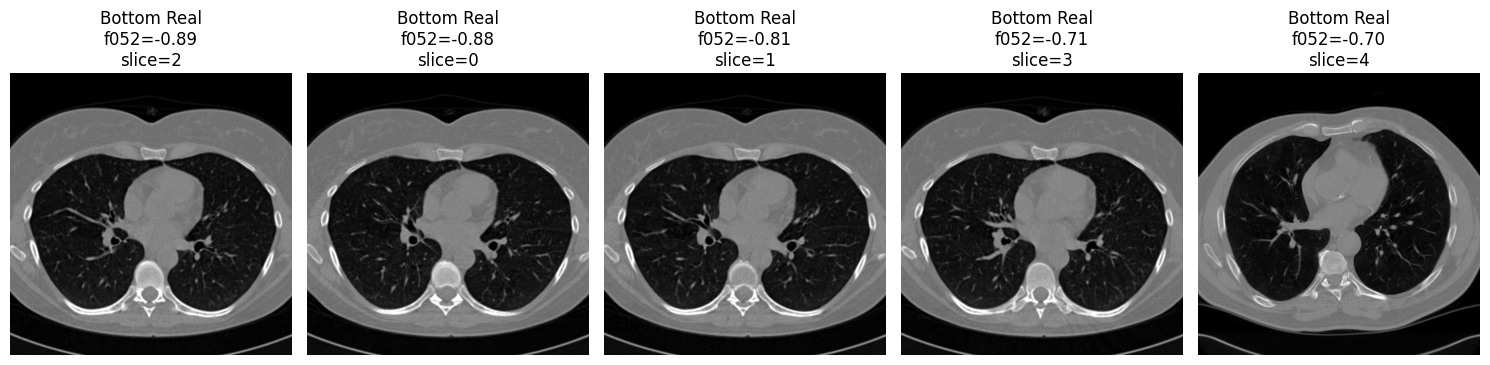

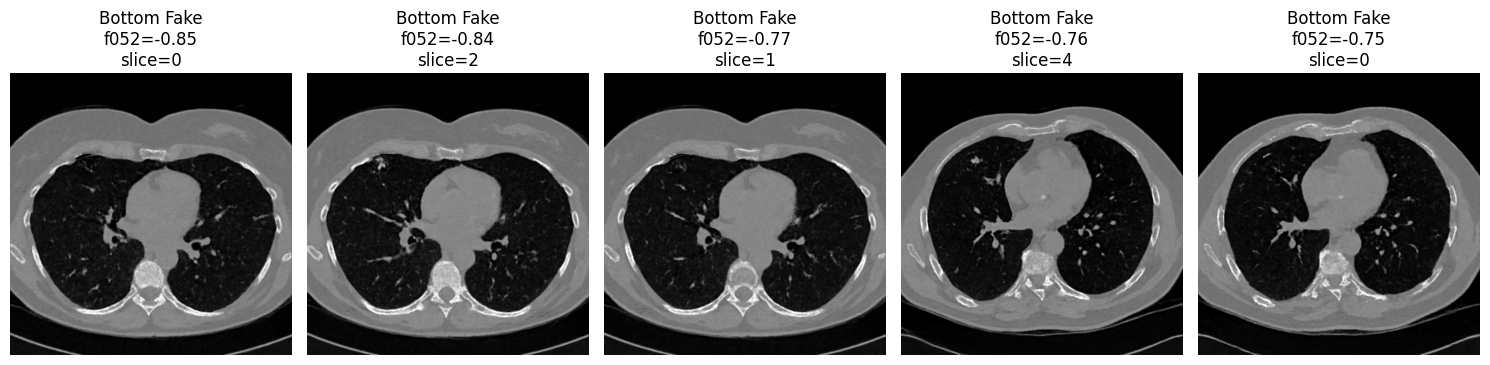

In [79]:
bottom_real = real.sort_values(by=feature, ascending=True).head(5)
bottom_fake = fake.sort_values(by=feature, ascending=True).head(5)

show_feature_slices(bottom_real, feature, "Bottom Real")
show_feature_slices(bottom_fake, feature, "Bottom Fake")

In [43]:
def show_feature_slices(df_subset, feature_name, title, n=5):
    plt.figure(figsize=(3 * n, 4))

    for i, row in enumerate(df_subset.head(n).itertuples(index=False)):
        vol = np.load(row.path)
        sidx = int(row.slice_idx)

        if vol.ndim == 3:
            if sidx < 0 or sidx >= vol.shape[0]:
                raise IndexError(f"slice_idx {sidx} out of range for volume shape {vol.shape}")
            img = vol[sidx]
        elif vol.ndim == 2:
            img = vol
        else:
            raise ValueError(f"Unsupported volume shape: {vol.shape}")

        ax = plt.subplot(1, n, i + 1)
        ax.imshow(img, cmap="gray")

        # highlight the panel with a colored border
        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

        ax.set_title(
            f"{title}\n{feature_name}={getattr(row, feature_name):.2f}\nslice={sidx}",
            color="red",
            fontsize=10,
            fontweight="bold"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

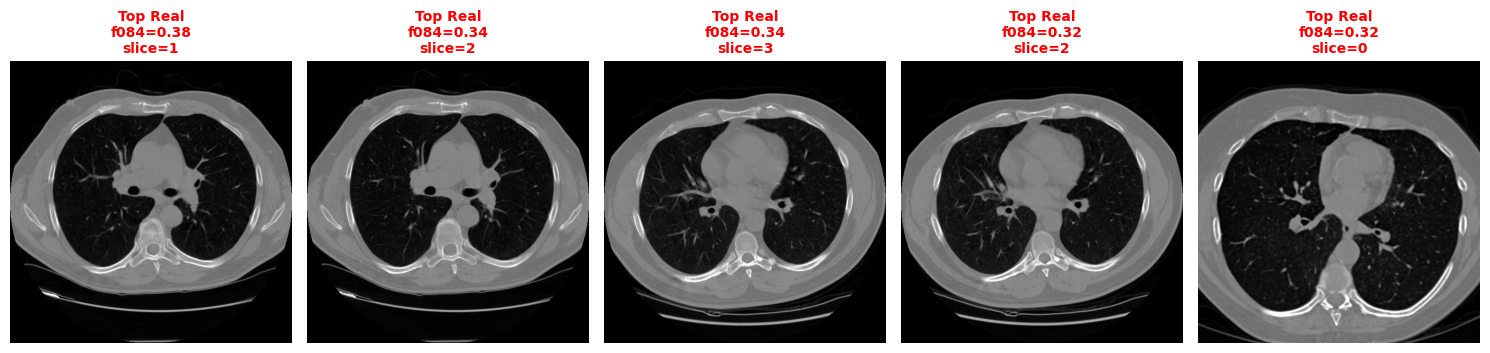

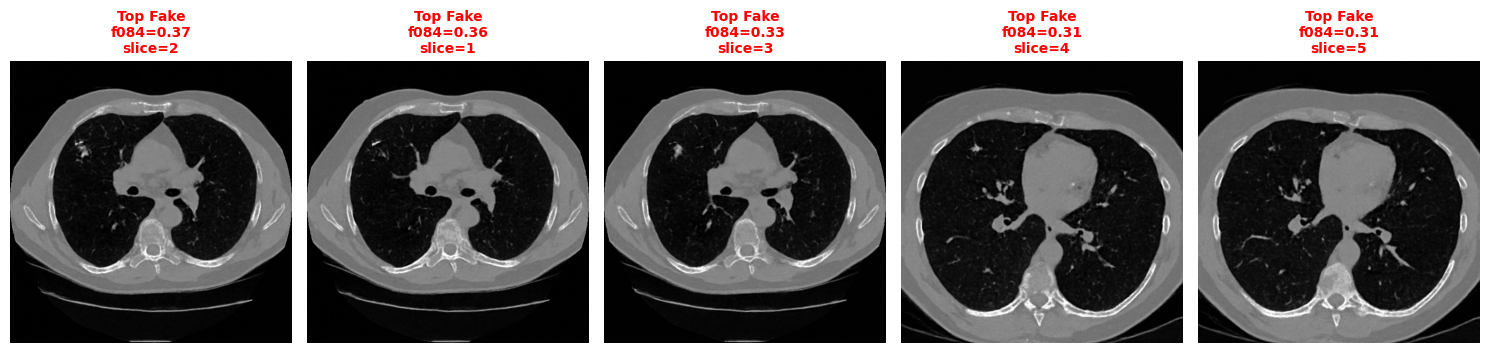

In [36]:
feature = "f084"

top_real = real.sort_values(by=feature, ascending=False).head(5)
top_fake = fake.sort_values(by=feature, ascending=False).head(5)

show_feature_slices(top_real, feature, "Top Real")
show_feature_slices(top_fake, feature, "Top Fake")

In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def highlight_feature_region(model, image_np, feature_idx=84):
    model.eval()

    # image_np should be a 2D slice
    x = torch.tensor(image_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    x.requires_grad_(True)

    output = model(x)   # expected shape: [1, 128] or similar
    target = output[0, feature_idx]

    model.zero_grad()
    target.backward()

    saliency = x.grad.abs().squeeze().detach().cpu().numpy()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image_np, cmap="gray")
    plt.title("Original Slice")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(saliency, cmap="jet", alpha=0.45)
    plt.title(f"Highlighted Region for f{feature_idx:03d}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

ModuleNotFoundError: No module named 'torch'